In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


#load results +units checkkkk
results_df = pd.read_csv("results.csv")

axes_order = ["d1", "d2", "d3", "d4"]

f_left_centers_mhz = np.array([
    float(results_df.loc[results_df["name"] == "d1_f_left_meas_MHz", "value"].iloc[0]),
    float(results_df.loc[results_df["name"] == "d2_f_left_meas_MHz", "value"].iloc[0]),
    float(results_df.loc[results_df["name"] == "d3_f_left_meas_MHz", "value"].iloc[0]),
    float(results_df.loc[results_df["name"] == "d4_f_left_meas_MHz", "value"].iloc[0]),
], dtype=float)

odmr_csv_path = "/home/vita/projects/NV_sensing/data/ODMR_avg_99-6dBm_0mW.csv"
odmr_df = pd.read_csv(odmr_csv_path, sep=r"\s+")
odmr_df.columns = [c.strip() for c in odmr_df.columns]

freq_col = [c for c in odmr_df.columns if "freq" in c.lower()][0]
sig_col = [c for c in odmr_df.columns if c != freq_col][0]

f_hz_odmr = odmr_df[freq_col].to_numpy(dtype=float)
y_raw_odmr = odmr_df[sig_col].to_numpy(dtype=float)

idx = np.argsort(f_hz_odmr)
f_hz_odmr = f_hz_odmr[idx]
y_raw_odmr = y_raw_odmr[idx]

f_mhz_odmr = f_hz_odmr / 1e6
f_ghz_odmr = f_hz_odmr / 1e9


# manually check for slope intervals extracted directly from data 


,axis,center_MHz,fit_start_MHz,fit_end_MHz,slope_raw_per_MHz,intercept_raw,n_points
0,d1,2791.205771,2788.0,2788.9,-0.005998,16.798954,5
1,d2,2803.935023,2801.0,2801.7,-0.006857,19.283244,4
2,d3,2855.262171,2852.0,2853.0,-0.002656,7.651833,6
3,d4,2866.883056,2863.9,2864.8,-0.001930,5.603410,5


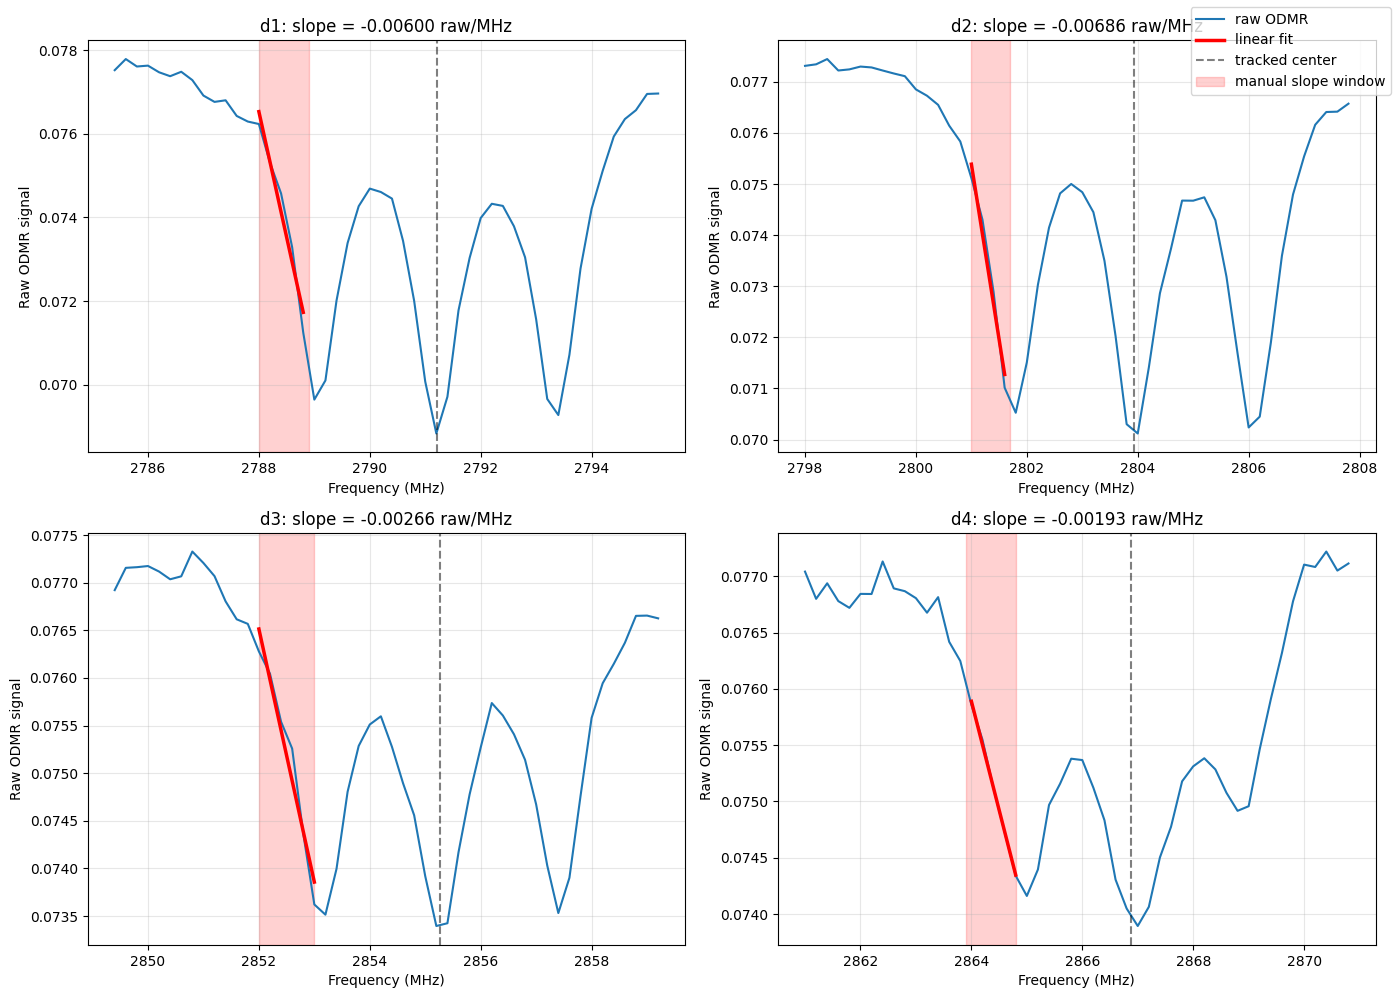

In [5]:
manual_windows = {
    "d1": (2788.0, 2788.9),
    "d2": (2801.0, 2801.7),
    "d3": (2852.0, 2853.0),
    "d4": (2863.9, 2864.8),
}

manual_windows

slope_rows = []

for ax_name in axes_order:
    f_min, f_max = manual_windows[ax_name]
    center = f_left_centers_mhz[axes_order.index(ax_name)]

    mask = (f_mhz_odmr >= f_min) & (f_mhz_odmr <= f_max)

    x_fit = f_mhz_odmr[mask]
    y_fit = y_raw_odmr[mask]

    coeffs = np.polyfit(x_fit, y_fit, deg=1)
    slope_raw_per_mhz = coeffs[0]
    intercept_raw = coeffs[1]

    slope_rows.append({
        "axis": ax_name,
        "center_MHz": center,
        "fit_start_MHz": f_min,
        "fit_end_MHz": f_max,
        "slope_raw_per_MHz": slope_raw_per_mhz,
        "intercept_raw": intercept_raw,
        "n_points": int(np.sum(mask))
    })

slopes_df = pd.DataFrame(slope_rows)
display(slopes_df)


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

left_span_mhz = 6.0
right_span_mhz = 4.0

for i, ax_name in enumerate(axes_order):
    center = slopes_df.loc[i, "center_MHz"]
    f_min = slopes_df.loc[i, "fit_start_MHz"]
    f_max = slopes_df.loc[i, "fit_end_MHz"]
    slope = slopes_df.loc[i, "slope_raw_per_MHz"]
    intercept = slopes_df.loc[i, "intercept_raw"]

    mask_zoom = (f_mhz_odmr >= center - left_span_mhz) & (f_mhz_odmr <= center + right_span_mhz)
    mask_fit = (f_mhz_odmr >= f_min) & (f_mhz_odmr <= f_max)

    x_fit = f_mhz_odmr[mask_fit]
    y_line = slope * x_fit + intercept

    axes[i].plot(f_mhz_odmr[mask_zoom], y_raw_odmr[mask_zoom], lw=1.5, label="raw ODMR")
    axes[i].plot(x_fit, y_line, color="red", lw=2.5, label="linear fit")
    axes[i].axvline(center, color="k", ls="--", alpha=0.5, label="tracked center" if i == 0 else None)
    axes[i].axvspan(f_min, f_max, color="red", alpha=0.18, label="manual slope window" if i == 0 else None)

    axes[i].set_title(f"{ax_name}: slope = {slope:.5f} raw/MHz")
    axes[i].set_xlabel("Frequency (MHz)")
    axes[i].set_ylabel("Raw ODMR signal")
    axes[i].grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.tight_layout()
plt.show()

# reconstruction- determine positive, negative, off times 

In [6]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

folder = "Avg_npy_pulse"
npy_files = sorted(glob.glob(os.path.join(folder, "Pulse_avg_d*.npy")))
axes_order = ["d1", "d2", "d3", "d4"]

all_data = [np.load(f) for f in npy_files]

print(all_data)

time = all_data[0][:, 0]
voltage_stack = np.stack([arr[:, 1:] for arr in all_data], axis=0)

n_timepoints = voltage_stack.shape[1]
n_pixels = voltage_stack.shape[2]

[array([[ 0.00000000e+00,  7.94575342e+01,  9.79260173e+01, ...,
         5.02662066e+01,  1.83949340e+02,  2.60874027e+02],
       [ 3.86400000e-04,  6.97000215e+01,  7.90484173e+01, ...,
         5.74127265e+01,  1.92701682e+02,  2.00465708e+02],
       [ 7.72800000e-04,  6.78735524e+01,  1.19341061e+02, ...,
        -2.67764658e+01,  1.81571253e+02,  2.52918467e+02],
       ...,
       [ 1.75425600e-01,  1.42452330e+02,  1.50832330e+02, ...,
         3.84248030e+01,  2.10439271e+02,  2.80793573e+02],
       [ 1.75812000e-01,  1.33712247e+02,  1.55024628e+02, ...,
        -6.84466224e+00,  2.08097958e+02,  2.69295398e+02],
       [ 1.76198400e-01,  1.59638301e+02,  1.50636199e+02, ...,
         1.93388140e+01,  2.30174943e+02,  2.33599573e+02]],
      shape=(457, 962)), array([[0.00000000e+00, 1.40353527e+01, 4.02364506e+00, ...,
        6.39354888e+01, 4.24899231e+01, 1.02095369e+02],
       [3.86400000e-04, 2.03529379e+01, 2.75272821e+01, ...,
        4.39097611e+01, 1.35727491e+02

In [7]:
grid_size = int(np.sqrt(n_pixels))
grid = np.zeros((grid_size, grid_size), dtype=int)

for idx in range(n_pixels):
    col = idx // grid_size
    row = idx % grid_size

    if col % 2 == 0:
        grid[grid_size - 1 - row, grid_size - 1 - col] = idx
    else:
        grid[row, grid_size - 1 - col] = idx

print("grid shape:", grid.shape)

grid shape: (31, 31)


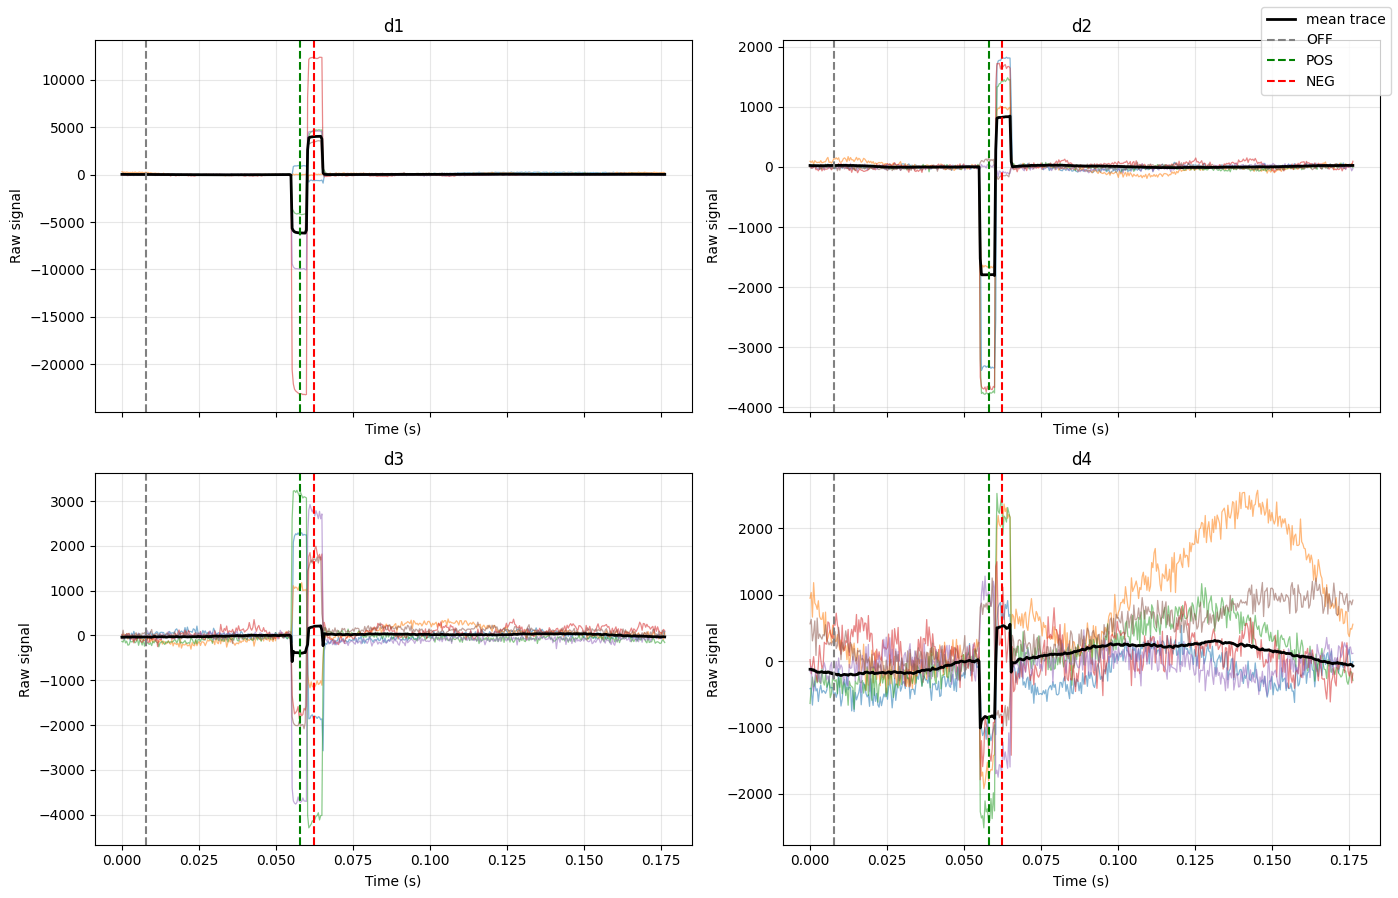

In [8]:
off_idx = 20
pos_idx = 150
neg_idx = 161

#visual check for intervals
pixel_list = [0, 100, 250, 450, 700, 900]
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
axes = axes.ravel()

for i, ax_name in enumerate(axes_order):
    ax = axes[i]

    for pix in pixel_list:
        ax.plot(time, voltage_stack[i, :, pix], lw=0.9, alpha=0.55)

    mean_trace = np.mean(voltage_stack[i], axis=1)
    ax.plot(time, mean_trace, color="black", lw=2.0, label="mean trace")

    ax.axvline(time[off_idx], color="gray", ls="--", lw=1.5, label="OFF" if i == 0 else None)
    ax.axvline(time[pos_idx], color="green", ls="--", lw=1.5, label="POS" if i == 0 else None)
    ax.axvline(time[neg_idx], color="red", ls="--", lw=1.5, label="NEG" if i == 0 else None)

    ax.set_title(ax_name)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Raw signal")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.tight_layout()
plt.show()

In [9]:

V_off = voltage_stack[:, off_idx, :]
V_pos = voltage_stack[:, pos_idx, :]
V_neg = voltage_stack[:, neg_idx, :]


extent_um = [-100, 100, -100, 100]

Voff_maps = V_off[:, grid]
Vpos_maps = V_pos[:, grid]
Vneg_maps = V_neg[:, grid]


dV_pos = V_pos - V_off
dV_neg = V_neg - V_off

dV_pos_maps = dV_pos[:, grid]
dV_neg_maps = dV_neg[:, grid]

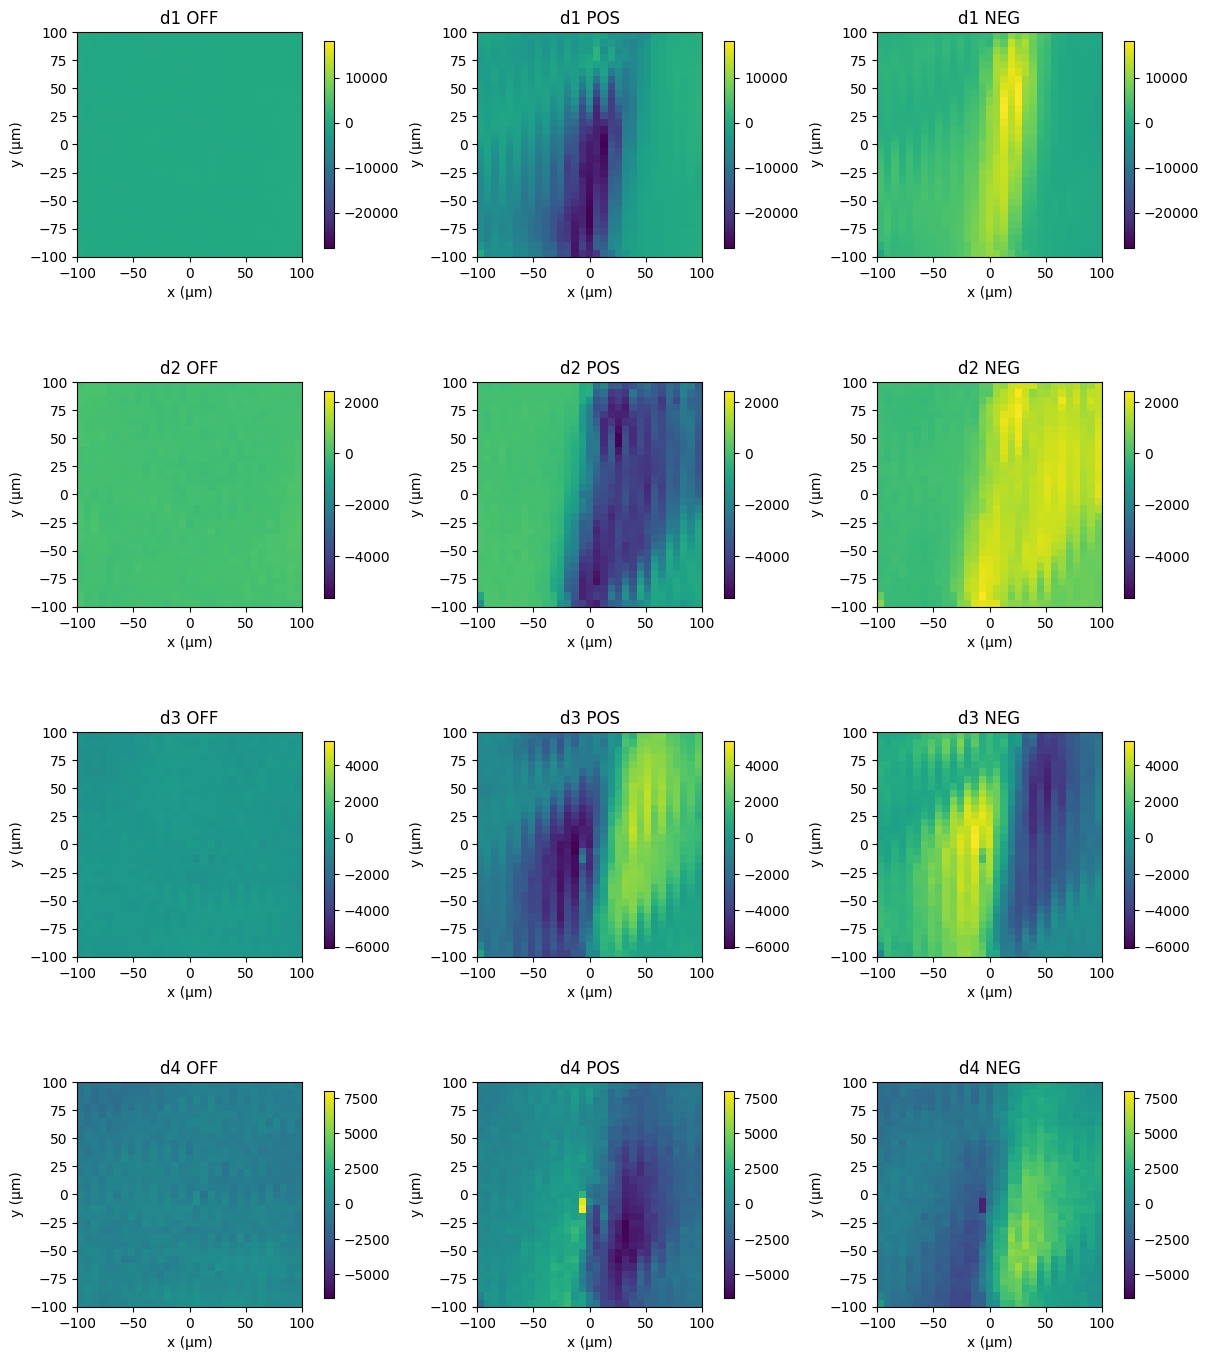

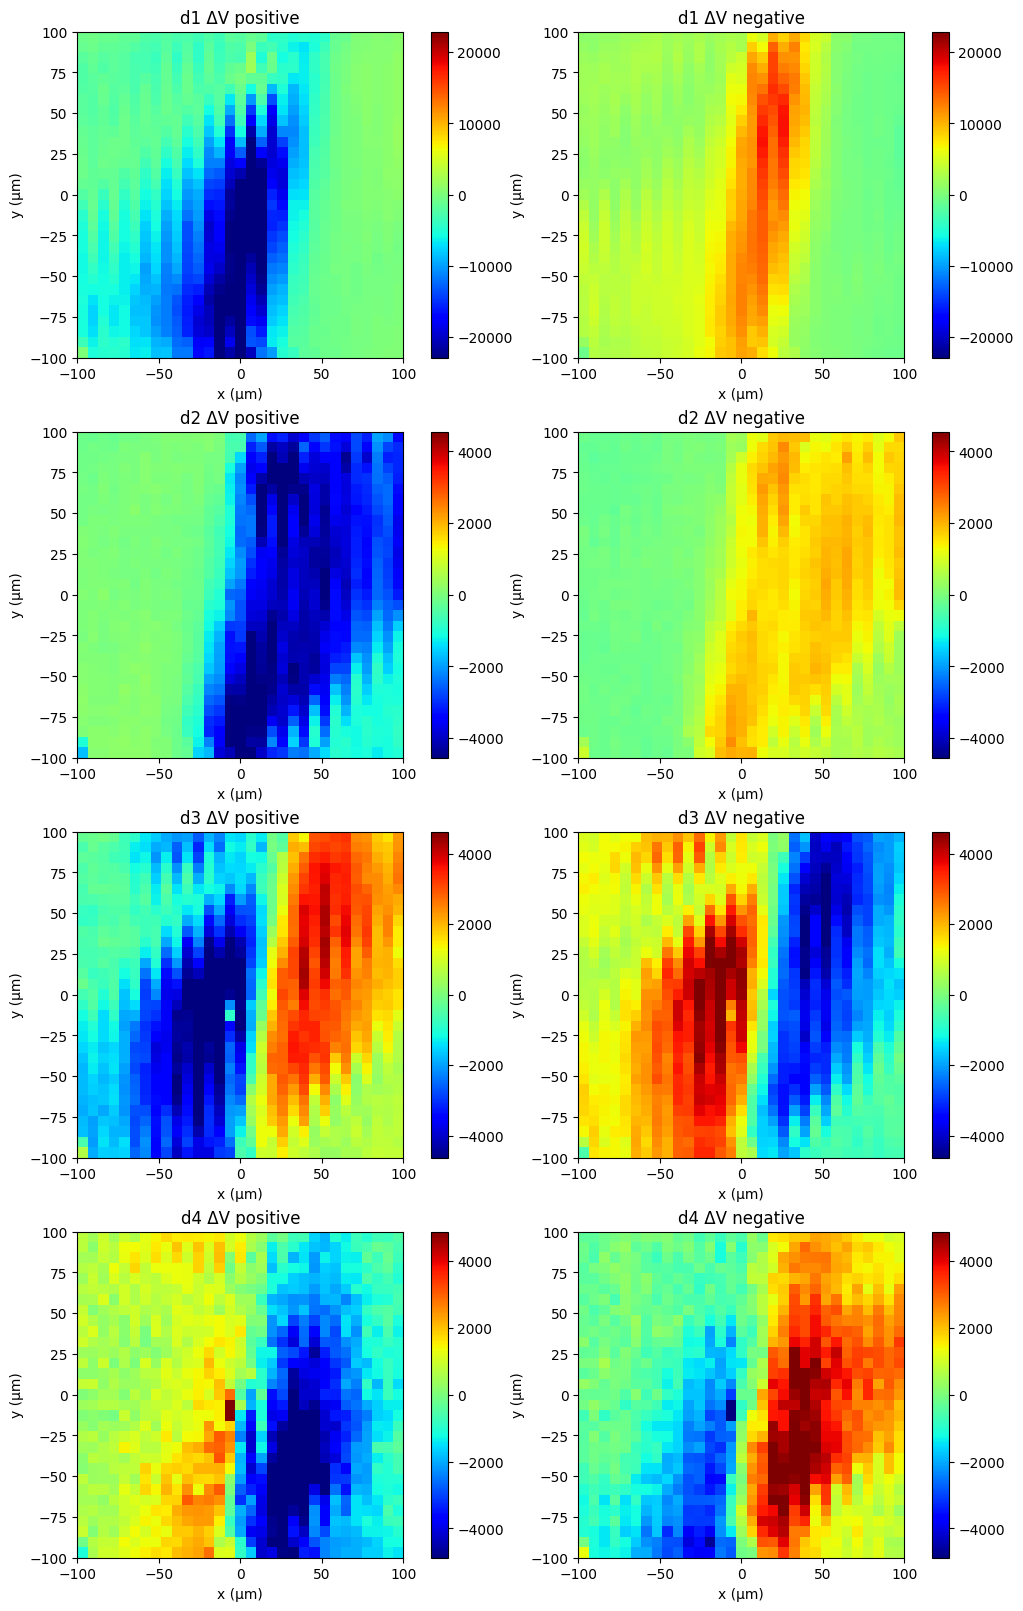

In [10]:


fig, axes = plt.subplots(4, 3, figsize=(12, 14), constrained_layout=True)

for i, ax_name in enumerate(axes_order):
    arrs = [Voff_maps[i], Vpos_maps[i], Vneg_maps[i]]
    titles = [f"{ax_name} OFF", f"{ax_name} POS", f"{ax_name} NEG"]

    vmin = min(np.nanmin(a) for a in arrs)
    vmax = max(np.nanmax(a) for a in arrs)

    for j in range(3):
        im = axes[i, j].imshow(
            arrs[j],
            extent=extent_um,
            origin="lower",
            aspect="equal",
            cmap="viridis",
            vmin=vmin,
            vmax=vmax
        )
        axes[i, j].set_title(titles[j])
        axes[i, j].set_xlabel("x (µm)")
        axes[i, j].set_ylabel("y (µm)")
        plt.colorbar(im, ax=axes[i, j], fraction=0.046, pad=0.04)

plt.show()


fig, axes = plt.subplots(4, 2, figsize=(10, 16), constrained_layout=True)

for i, ax_name in enumerate(axes_order):
    lim = max(
        np.nanpercentile(np.abs(dV_pos_maps[i]), 95),
        np.nanpercentile(np.abs(dV_neg_maps[i]), 95)
    )
    if lim == 0:
        lim = 1.0

    im1 = axes[i, 0].imshow(
        dV_pos_maps[i],
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap="jet",
        vmin=-lim,
        vmax=lim
    )
    axes[i, 0].set_title(f"{ax_name} ΔV positive")
    axes[i, 0].set_xlabel("x (µm)")
    axes[i, 0].set_ylabel("y (µm)")
    plt.colorbar(im1, ax=axes[i, 0], fraction=0.046, pad=0.04)

    im2 = axes[i, 1].imshow(
        dV_neg_maps[i],
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap="jet",
        vmin=-lim,
        vmax=lim
    )
    axes[i, 1].set_title(f"{ax_name} ΔV negative")
    axes[i, 1].set_xlabel("x (µm)")
    axes[i, 1].set_ylabel("y (µm)")
    plt.colorbar(im2, ax=axes[i, 1], fraction=0.046, pad=0.04)

plt.show()

In [11]:
slopes_raw_per_MHz = slopes_df["slope_raw_per_MHz"].to_numpy(dtype=float)
slopes_raw_abs_per_MHz = np.abs(slopes_raw_per_MHz)

deltaNu_pos = dV_pos / slopes_raw_abs_per_MHz[:, None]
deltaNu_neg = dV_neg / slopes_raw_abs_per_MHz[:, None]

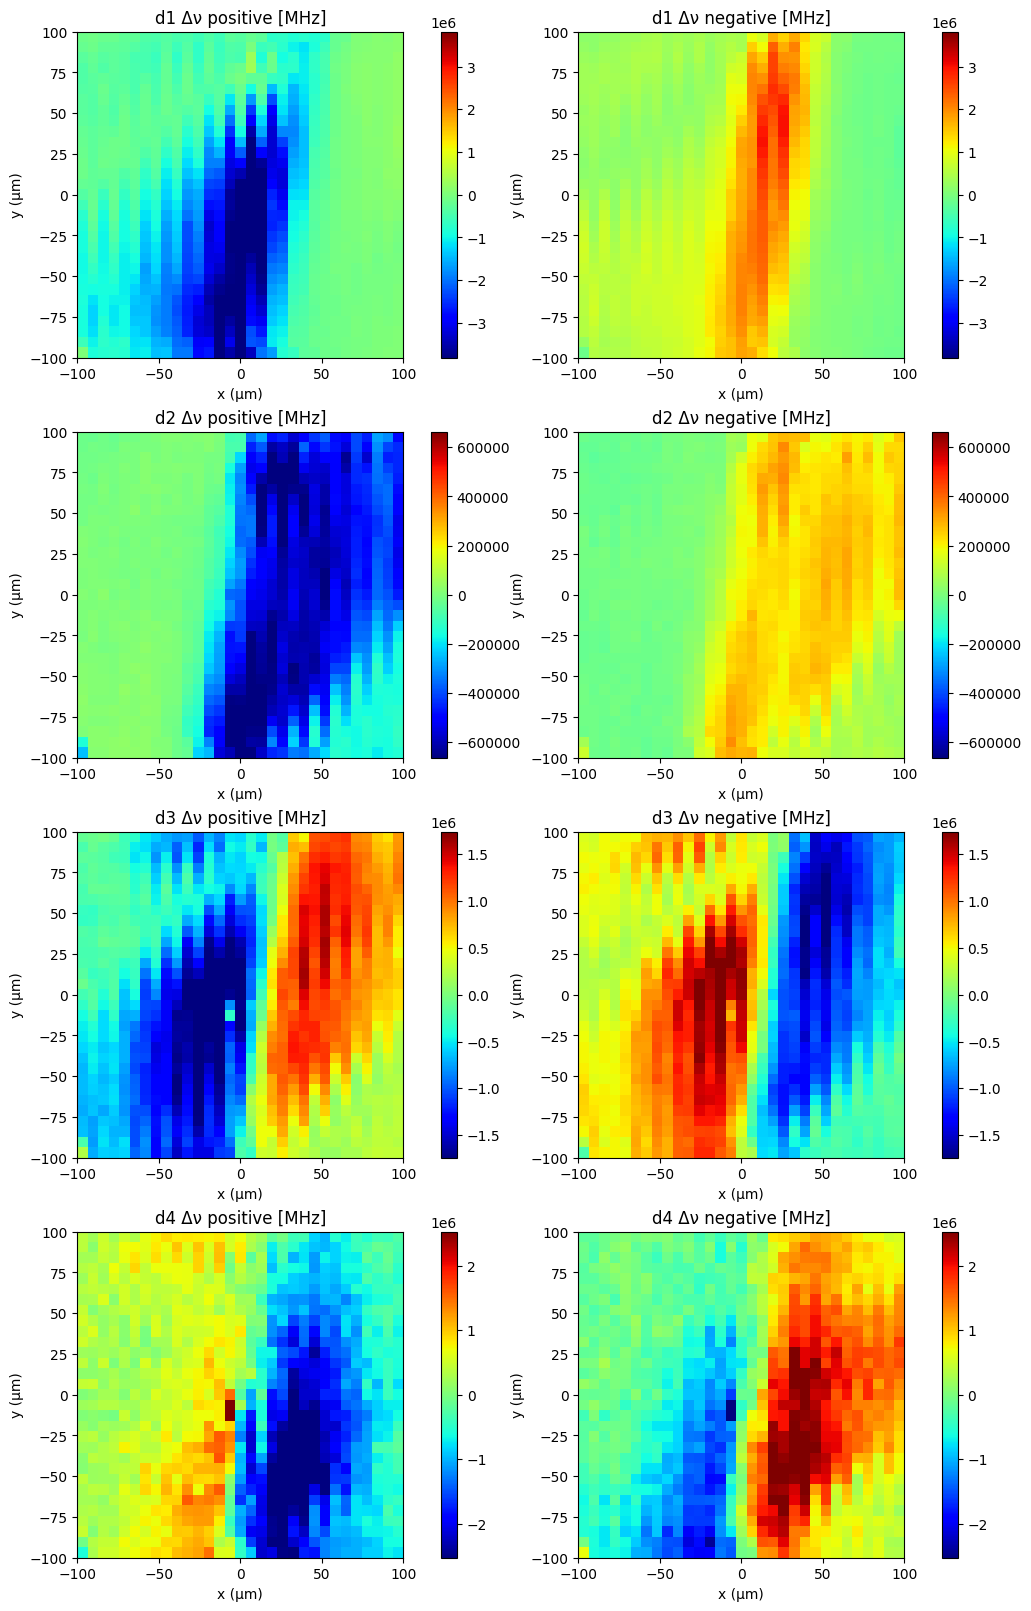

In [12]:
deltaNu_pos_maps = deltaNu_pos[:, grid]
deltaNu_neg_maps = deltaNu_neg[:, grid]

fig, axes = plt.subplots(4, 2, figsize=(10, 16), constrained_layout=True)

for i, ax_name in enumerate(axes_order):
    lim = max(
        np.nanpercentile(np.abs(deltaNu_pos_maps[i]), 95),
        np.nanpercentile(np.abs(deltaNu_neg_maps[i]), 95)
    )
    if lim == 0:
        lim = 1.0

    im1 = axes[i, 0].imshow(
        deltaNu_pos_maps[i],
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap="jet",
        vmin=-lim,
        vmax=lim
    )
    axes[i, 0].set_title(f"{ax_name} Δν positive [MHz]")
    axes[i, 0].set_xlabel("x (µm)")
    axes[i, 0].set_ylabel("y (µm)")
    plt.colorbar(im1, ax=axes[i, 0], fraction=0.046, pad=0.04)

    im2 = axes[i, 1].imshow(
        deltaNu_neg_maps[i],
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap="jet",
        vmin=-lim,
        vmax=lim
    )
    axes[i, 1].set_title(f"{ax_name} Δν negative [MHz]")
    axes[i, 1].set_xlabel("x (µm)")
    axes[i, 1].set_ylabel("y (µm)")
    plt.colorbar(im2, ax=axes[i, 1], fraction=0.046, pad=0.04)

plt.show()

A_plus [mT/MHz]:
 [[-0.00196802 -0.00292597 -0.02287232 -0.02238438]
 [-0.02295424 -0.02253042 -0.00040755 -0.00032227]
 [-0.01562025  0.01578408 -0.01386735  0.01475487]]


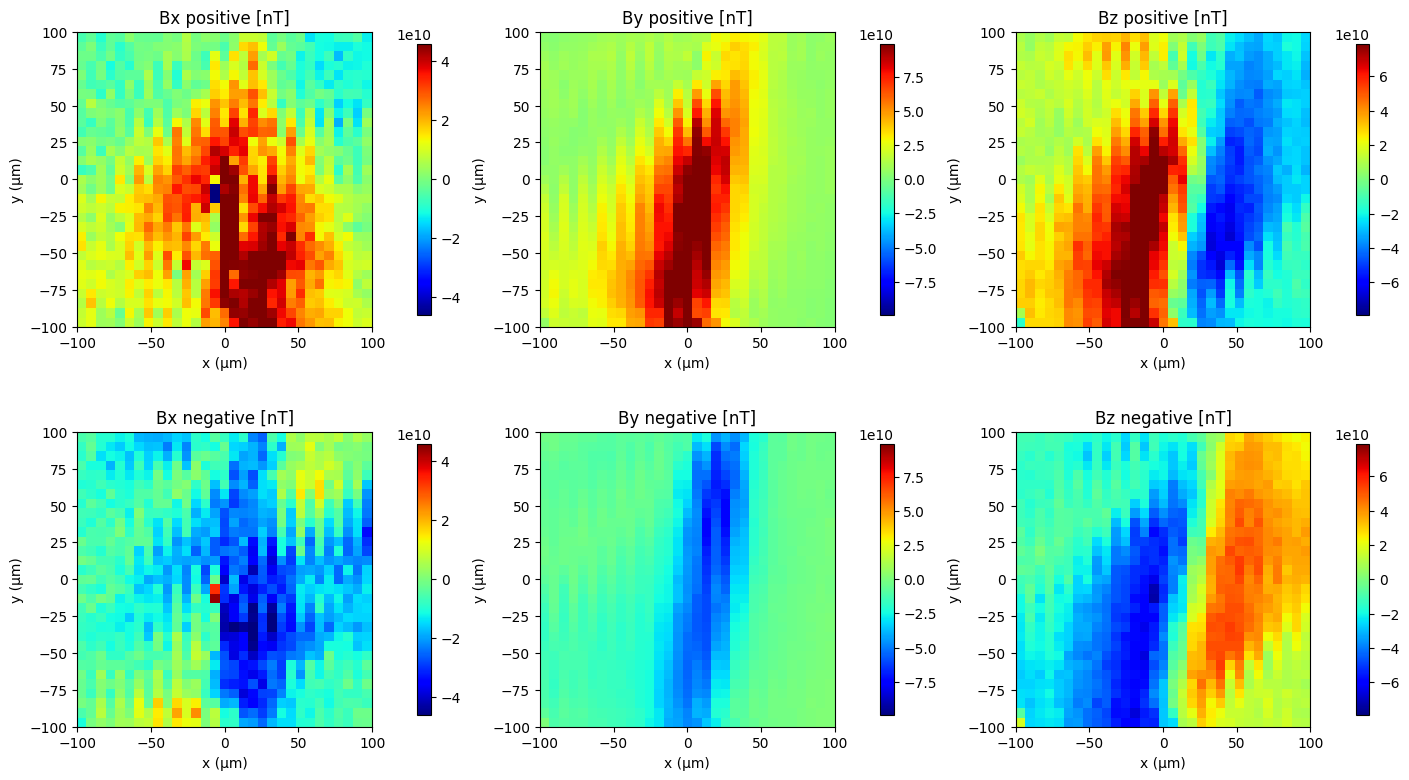

In [13]:
#now lets apply A, load it 

A_results_df = pd.read_csv("A_results.csv")

A_plus = np.zeros((3, 4), dtype=float)

for i, comp in enumerate(["Bx", "By", "Bz"]):
    for j, ax_name in enumerate(axes_order):
        A_plus[i, j] = float(
            A_results_df.loc[
                (A_results_df["group"] == "A_plus") &
                (A_results_df["row"] == comp) &
                (A_results_df["col"] == ax_name),
                "value"
            ].iloc[0]
        )

print("A_plus [mT/MHz]:\n", A_plus)


B_pos_mT = A_plus @ deltaNu_pos
B_neg_mT = A_plus @ deltaNu_neg

B_pos_nT = 1e6 * B_pos_mT
B_neg_nT = 1e6 * B_neg_mT

Bx_pos_map = B_pos_nT[0][grid]
By_pos_map = B_pos_nT[1][grid]
Bz_pos_map = B_pos_nT[2][grid]

Bx_neg_map = B_neg_nT[0][grid]
By_neg_map = B_neg_nT[1][grid]
Bz_neg_map = B_neg_nT[2][grid]

Bx_lim = max(np.nanpercentile(np.abs(Bx_pos_map), 95),
             np.nanpercentile(np.abs(Bx_neg_map), 95))
By_lim = max(np.nanpercentile(np.abs(By_pos_map), 95),
             np.nanpercentile(np.abs(By_neg_map), 95))
Bz_lim = max(np.nanpercentile(np.abs(Bz_pos_map), 95),
             np.nanpercentile(np.abs(Bz_neg_map), 95))

fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

maps = [
    ("Bx positive [nT]", Bx_pos_map, Bx_lim),
    ("By positive [nT]", By_pos_map, By_lim),
    ("Bz positive [nT]", Bz_pos_map, Bz_lim),
    ("Bx negative [nT]", Bx_neg_map, Bx_lim),
    ("By negative [nT]", By_neg_map, By_lim),
    ("Bz negative [nT]", Bz_neg_map, Bz_lim),
]

for ax, (title, data, lim) in zip(axes.ravel(), maps):
    if lim == 0:
        lim = 1.0

    im = ax.imshow(
        data,
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap="jet",
        vmin=-lim,
        vmax=lim
    )
    ax.set_title(title)
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.show()